In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [3]:
from mapcharting.io.dichasus_dataset import load_calibrate_timedomain

2026-03-21 10:51:06.917914: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
files = [
    {
        "tfrecords": "data/dichasus/dichasus-cf02.tfrecords",
        "offsets": "data/dichasus/reftx-offsets-dichasus-cf02.json",
    },
    {
        "tfrecords": "data/dichasus/dichasus-cf03.tfrecords",
        "offsets": "data/dichasus/reftx-offsets-dichasus-cf03.json",
    },
    {
        "tfrecords": "data/dichasus/dichasus-cf04.tfrecords",
        "offsets": "data/dichasus/reftx-offsets-dichasus-cf04.json",
    }
]


In [11]:
dataset = load_calibrate_timedomain(files[0]["tfrecords"], files[0]["offsets"])

for path in files[1:]:
	dataset = dataset.concatenate(load_calibrate_timedomain(path["tfrecords"], path["offsets"]))

In [12]:
training_set = dataset.shard(4, 0)

In [13]:
groundtruth_positions = []
csi_time_domain = []
timestamps = []

for csi, pos, time in training_set.batch(1000):
    csi_time_domain.append(csi.numpy())
    groundtruth_positions.append(pos.numpy())
    timestamps.append(time.numpy())

csi_time_domain = np.concatenate(csi_time_domain)
groundtruth_positions = np.concatenate(groundtruth_positions)
timestamps = np.concatenate(timestamps)

2026-03-21 10:53:28.512730: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
np.savez('data/csi', csi_time_domain)
np.savez('data/positions', groundtruth_positions)
np.savez('data/timestamps', timestamps)

In [14]:
def plot_colorized(positions, groundtruth_positions, title = None, show = True, alpha = 1.0):
    # Generate RGB colors for datapoints
    center_point = np.zeros(2, dtype = np.float32)
    center_point[0] = 0.5 * (np.min(groundtruth_positions[:, 0], axis = 0) + np.max(groundtruth_positions[:, 0], axis = 0))
    center_point[1] = 0.5 * (np.min(groundtruth_positions[:, 1], axis = 0) + np.max(groundtruth_positions[:, 1], axis = 0))
    def NormalizeData(in_data):
        return (in_data - np.min(in_data)) / (np.max(in_data) - np.min(in_data))
    rgb_values = np.zeros((groundtruth_positions.shape[0], 3))
    rgb_values[:, 0] = 1 - 0.9 * NormalizeData(groundtruth_positions[:, 0])
    rgb_values[:, 1] = 0.8 * NormalizeData(np.square(np.linalg.norm(groundtruth_positions[:,0:2] - center_point, axis=1)))
    rgb_values[:, 2] = 0.9 * NormalizeData(groundtruth_positions[:, 1])

    # Plot datapoints
    plt.figure(figsize=(6, 6))
    if title is not None:
        plt.title(title, fontsize=16)
    plt.scatter(positions[:, 0], positions[:, 1], c = rgb_values, alpha = alpha, s = 10, linewidths = 0)
    plt.xlabel("x coordinate")
    plt.ylabel("y coordinate")
    if show:
        plt.show()

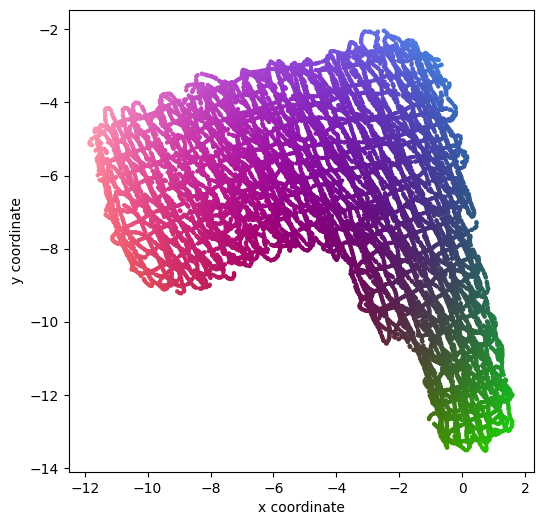

In [15]:
plot_colorized(groundtruth_positions, groundtruth_positions)